# SMWA 20261 — Predictive Modelling Suite
## Multi-Algorithm Comparison for Movie Box Office Revenue Prediction
---
**Module:** Social Media and Web Analytics (SMWA_20261)

### Algorithms Compared Per Task

| Task | Algorithms |
|------|------------|
| Sentiment Classification | Logistic Regression, SVM, K-Nearest Neighbors, Gradient Boosting, Random Forest |
| IMDb Rating Forecast | Linear Regression, Ridge, Lasso, Gradient Boosting, Random Forest |
| Box Office Revenue Forecast | Linear Regression, Ridge, Lasso, Gradient Boosting, Random Forest |

### Pipeline
```
Step 1  → Import Libraries
Step 2  → Load Raw Dataset (2,500 review-level rows)
Step 3  → Exploratory Data Analysis (EDA)
Step 4  → NLP Feature Engineering — VADER Sentiment
Step 5  → Aggregate to Movie-Level Dataset (100 unique films)
Step 6  → Train/Test Split (75 train / 25 test, stratified)
Step 7  → Model I  — Audience Sentiment Classifier (5 algorithms)
Step 8  → Model II — IMDb Rating Forecaster (5 algorithms)
Step 9  → Model III — Box Office Revenue Predictor (5 algorithms)
Step 10 → Cross-Model Comparison & Business Interpretation
```

## Step 1 — Import Libraries

In [23]:
# ── Standard ─────────────────────────────────────────────────────────────────
import pandas  as pd
import numpy   as np
import warnings
warnings.filterwarnings('ignore')

# ── Classical ML — Classification ────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier

# ── Classical ML — Regression ────────────────────────────────────────────────
from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm             import SVR

# ── Pre-processing & Evaluation ───────────────────────────────────────────────
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.metrics         import (accuracy_score, f1_score, precision_score,
                                      recall_score, classification_report, confusion_matrix,
                                      r2_score, mean_squared_error, mean_absolute_error)

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

# ── Visualisation ─────────────────────────────────────────────────────────────
import plotly.express        as px
import plotly.graph_objects  as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

np.random.seed(42)

print('✅ All libraries imported successfully.')
print()
print('Classification algorithms : Logistic Regression | SVM | KNN | Gradient Boosting | Random Forest')
print('Regression algorithms     : Linear Regression | Ridge | Lasso | Gradient Boosting | Random Forest')

✅ All libraries imported successfully.

Classification algorithms : Logistic Regression | SVM | KNN | Gradient Boosting | Random Forest
Regression algorithms     : Linear Regression | Ridge | Lasso | Gradient Boosting | Random Forest


## Step 2 — Load Raw Dataset

In [24]:
df_raw = pd.read_csv('movie_data_professional.csv')

print('=' * 65)
print('RAW DATASET — OVERVIEW')
print('=' * 65)
print(f'Rows            : {df_raw.shape[0]:,}')
print(f'Columns         : {df_raw.shape[1]}')
print(f'Unique movies   : {df_raw["Movie Title"].nunique()}')
print(f'Reviews / movie : {df_raw.shape[0] / df_raw["Movie Title"].nunique():.0f} (average)')
print(f'Year range      : {df_raw["Year"].min()} – {df_raw["Year"].max()}')
print(f'Platforms       : {df_raw["Platform"].unique().tolist()}')
print(f'Missing values  : {df_raw.isnull().sum().sum()}')
print()
print('Column list:', list(df_raw.columns))
print()
df_raw.head()

RAW DATASET — OVERVIEW
Rows            : 3,564
Columns         : 14
Unique movies   : 100
Reviews / movie : 36 (average)
Year range      : 1971 – 2021
Platforms       : ['IMDb', 'Reddit']
Missing values  : 0

Column list: ['Movie Title', 'Platform', 'Review_Text', 'Year', 'Budget_M', 'BoxOffice_M', 'IMDb_Rating', 'Reviewer', 'ROI', 'Sentiment_Class', 'BERT_Sentiment', 'BERT_Confidence', 'Review_Year', 'Review_Rating']



,Movie Title,Platform,Review_Text,Year,Budget_M,BoxOffice_M,IMDb_Rating,Reviewer,ROI,Sentiment_Class,BERT_Sentiment,BERT_Confidence,Review_Year,Review_Rating
0,The Shawshank Redemption,IMDb,This movie should have been named Need For Spe...,1991,112,475.17,9.0,User_47099,4.242589,Positive,Negative,0.993472,1997,8.6
1,The Shawshank Redemption,IMDb,My baby sitter was a fan so I saw many of the ...,1991,112,475.17,9.0,User_68496,4.242589,Positive,Positive,0.993704,1994,9.5
2,The Shawshank Redemption,IMDb,This film is about a Japanese woman who has an...,1991,112,475.17,9.0,User_67093,4.242589,Positive,Negative,0.999008,1998,9.2
3,The Shawshank Redemption,IMDb,"This is a really bad film, with bad acting and...",1991,112,475.17,9.0,User_30689,4.242589,Positive,Negative,0.998339,1995,8.2
4,The Shawshank Redemption,IMDb,"Merry madcaps in London stage a treasure hunt,...",1991,112,475.17,9.0,User_49651,4.242589,Positive,Negative,0.889939,1997,8.8


## Step 3 — Exploratory Data Analysis

In [25]:
num_cols = ['Budget_M','BoxOffice_M','IMDb_Rating','ROI']
print('── Descriptive Statistics ──────────────────────────────────────────────────')
display(df_raw[num_cols].describe().round(3))

# Unique-film view
films = df_raw.drop_duplicates('Movie Title').copy()

# Fig 1: Budget vs Box Office
fig1 = px.scatter(
    films, x='Budget_M', y='BoxOffice_M', hover_name='Movie Title',
    trendline='ols', color='Platform', size='IMDb_Rating',
    title='Fig 1 — Budget vs Box Office Revenue (100 unique films)',
    labels={'Budget_M':'Budget ($M)','BoxOffice_M':'Box Office ($M)'},
    template='plotly_dark'
)
fig1.show()

# Fig 2: IMDb Rating distribution
fig2 = px.histogram(
    films, x='IMDb_Rating', nbins=20, color='Platform',
    title='Fig 2 — IMDb Rating Distribution (100 films)',
    template='plotly_dark', barmode='overlay'
)
fig2.show()

# Fig 3: Correlation heatmap
corr = films[num_cols].corr().round(3)
fig3 = px.imshow(corr, text_auto=True, aspect='auto',
    title='Fig 3 — Feature Correlation Matrix',
    template='plotly_dark', color_continuous_scale='RdBu_r')
fig3.show()

print('Key correlations (unique films):')
print(f'  Budget ↔ Box Office : r = {corr.loc["Budget_M","BoxOffice_M"]:.3f}')
print(f'  Rating ↔ Box Office : r = {corr.loc["IMDb_Rating","BoxOffice_M"]:.3f}')
print(f'  Budget ↔ Rating     : r = {corr.loc["Budget_M","IMDb_Rating"]:.3f}')

── Descriptive Statistics ──────────────────────────────────────────────────


,Budget_M,BoxOffice_M,IMDb_Rating,ROI
count,3564.000,3564.000,3564.000,3564.000
mean,89.939,617.908,8.717,6.336
std,52.851,614.326,0.401,3.145
min,11.000,56.450,7.800,2.566
25%,57.000,190.540,8.300,2.887
50%,66.000,452.670,8.800,5.670
75%,118.000,754.300,9.100,9.153
max,385.000,2938.770,9.300,11.948


Key correlations (unique films):
  Budget ↔ Box Office : r = 0.812
  Rating ↔ Box Office : r = 0.010
  Budget ↔ Rating     : r = -0.091


## Step 4 — NLP Feature Engineering (VADER Sentiment Analysis)
**VADER** (Hutto & Gilbert, 2014) computes four scores per review:
- `compound` (−1 to +1): overall polarity
- `pos / neg / neu`: proportions of sentiment language.

In [26]:
# Deep Learning sentiment (BERT) is naturally loaded from movie_data_professional.csv


### Longitudinal Sentiment Validation
We now track true sentiment shifting across movie release years natively using BERT labels.

In [27]:
# ── Fig 5a: Longitudinal Sentiment Tracking over Time ─────────────────────────
import plotly.express as px

# Group original raw data by Release Year to get organic sentiment variance over time
time_df = df_raw.groupby('Year').agg(
    Total_Reviews=('Review_Text', 'count'),
    Pos_Reviews=('BERT_Sentiment', lambda x: (x == 'Positive').sum())
).reset_index()

# Calculate pure positive sentiment ratio
time_df['Sentiment_Positivity_Ratio'] = time_df['Pos_Reviews'] / time_df['Total_Reviews']

fig_ts = px.line(time_df, x='Year', y='Sentiment_Positivity_Ratio', 
              markers=True, 
              title='Fig 5a — Evolution of Movie Sentiment Over Decades (Time-Series)',
              labels={'Sentiment_Positivity_Ratio': 'Positive Sentiment Ratio (%)', 'Year': 'Release Year'},
              template='plotly_dark')
fig_ts.update_traces(line_color='#00ffcc', marker=dict(size=8, color='#ff007f'))
fig_ts.update_layout(yaxis_tickformat='.0%')
fig_ts.show()

## Step 5 — Aggregate to Movie-Level Dataset
**Why?** The raw CSV has multiple reviews per film. We must aggregate to provide features for Rating and Revenue prediction.

In [28]:
# Deep Learning sentiment processing
df_raw['Is_Pos'] = (df_raw['BERT_Sentiment'] == 'Positive').astype(int)
df_raw['Is_Neg'] = (df_raw['BERT_Sentiment'] == 'Negative').astype(int)

# Restore syntactic text features
df_raw['Review_Len'] = df_raw['Review_Text'].astype(str).str.len()
df_raw['Num_Exclamations'] = df_raw['Review_Text'].astype(str).str.count('!')
df_raw['Num_QuestionMarks'] = df_raw['Review_Text'].astype(str).str.count('\\?')

movie_df = df_raw.groupby(
    ['Movie Title','Platform','Year','Budget_M','BoxOffice_M','IMDb_Rating']
).agg(
    Pct_BERT_Positive = ('Is_Pos', 'mean'),
    Pct_BERT_Negative = ('Is_Neg', 'mean'),
    Avg_BERT_Confidence = ('BERT_Confidence', 'mean'),
    Avg_Review_Len   = ('Review_Len', 'mean'),
    Avg_Exclamations = ('Num_Exclamations', 'mean'),
    Avg_Questions    = ('Num_QuestionMarks', 'mean')
).reset_index()

# Restore ROI
movie_df['ROI'] = (movie_df['BoxOffice_M'] / movie_df['Budget_M']).fillna(0)

# Create target label for Sentiment Classifier (Model I)
movie_df['Target_Sentiment_Class'] = np.where(movie_df['Pct_BERT_Positive'] >= 0.50, 1, 0)
movie_df['Platform_Encoded'] = movie_df['Platform'].map({'IMDb': 0, 'Reddit': 1}).fillna(0)

display(movie_df.head(3))

,Movie Title,Platform,Year,Budget_M,BoxOffice_M,IMDb_Rating,Pct_BERT_Positive,Pct_BERT_Negative,Avg_BERT_Confidence,Avg_Review_Len,Avg_Exclamations,Avg_Questions,ROI,Target_Sentiment_Class,Platform_Encoded
0,12 Angry Men,IMDb,1990,149,629.87,8.1,0.500000,0.500000,0.994820,1979.625000,3.000000,0.625000,4.227315,1,0
1,A Beautiful Mind,IMDb,1993,62,572.55,8.6,0.295455,0.704545,0.952909,1179.454545,1.045455,0.704545,9.234677,0,0
2,A Clockwork Orange,Reddit,1991,71,557.43,8.8,0.200000,0.800000,0.999461,547.600000,1.200000,0.200000,7.851127,0,1


## Step 7 — Advanced NLP Text Classification (Model I)
Here we construct an academically rigorous **Deep Text Classification** pipeline.
Rather than using aggregated dataset variables, we process the **raw textual strings** using three prominent encoding strategies:
1. **Bag of Words (CountVectorizer)**
2. **TF-IDF (TfidfVectorizer)**
3. **Word2Vec Embeddings (Gensim)**

We subsequently run 5 Machine Learning algorithms across these 3 pipelines incorporating **Regularization** and **5-Fold Cross Validation**.

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Prepare Raw NLP Dataset
text_data = df_raw['Review_Text'].fillna("").astype(str).values
y_raw = (df_raw['BERT_Sentiment'] == 'Positive').astype(int).values

X_text_train, X_text_test, y_nlp_train, y_nlp_test = train_test_split(
    text_data, y_raw, test_size=0.25, random_state=42, stratify=y_raw
)

# 1. BAG OF WORDS
vectorizer_bow = CountVectorizer(max_features=2500, stop_words='english')
X_bow_train = vectorizer_bow.fit_transform(X_text_train).toarray()
X_bow_test  = vectorizer_bow.transform(X_text_test).toarray()

# 2. TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=2500, stop_words='english')
X_tfidf_train = vectorizer_tfidf.fit_transform(X_text_train).toarray()
X_tfidf_test  = vectorizer_tfidf.transform(X_text_test).toarray()

# 3. WORD2VEC (Custom Trained)
tokenized_train = [doc.split() for doc in X_text_train]
tokenized_test  = [doc.split() for doc in X_text_test]
w2v_model = Word2Vec(sentences=tokenized_train, vector_size=100, window=5, min_count=2, workers=4)

def document_vector(doc_tokens, model):
    valid_tokens = [word for word in doc_tokens if word in model.wv.index_to_key]
    if not valid_tokens: return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_tokens], axis=0)

X_w2v_train = np.array([document_vector(d, w2v_model) for d in tokenized_train])
X_w2v_test  = np.array([document_vector(d, w2v_model) for d in tokenized_test])
X_w2v_train_sc = StandardScaler().fit_transform(X_w2v_train)
X_w2v_test_sc  = StandardScaler().fit_transform(X_w2v_test)

In [30]:
# ── NLP CLASSIFICATION ENGINE WITH REGULARIZATION & CV ────────────────────────
classifiers = {
    'Logistic Regression (Base)': LogisticRegression(max_iter=500),
    'Logistic Regression (L2 Reg)': LogisticRegression(max_iter=500, C=0.1, penalty='l2'),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree (Pruned)': DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'SVM (Linear C=0.5)': SVC(kernel='linear', C=0.5, probability=True)
}

feature_spaces = {
    'Bag-of-Words': (X_bow_train, X_bow_test),
    'TF-IDF': (X_tfidf_train, X_tfidf_test),
    'Word2Vec': (X_w2v_train_sc, X_w2v_test_sc)
}

cv_summary1 = {}
nlp_results = []

for space_name, (X_tr, X_te) in feature_spaces.items():
    for clf_name, clf in classifiers.items():
        m = clf
        if clf_name == 'Naive Bayes' and space_name == 'Word2Vec': m = GaussianNB()
        cv_scores = cross_val_score(m, X_tr, y_nlp_train, cv=5)
        m.fit(X_tr, y_nlp_train)
        acc = m.score(X_te, y_nlp_test)
        
        # Save for master table
        full_name = f"{clf_name} ({space_name})"
        cv_summary1[full_name] = cv_scores
        
        nlp_results.append({
            'Matrix': space_name,
            'Algorithm': clf_name,
            'CV Acc': cv_scores.mean(),
            'Test Acc': acc
        })

nlp_results_df = pd.DataFrame(nlp_results)
display(nlp_results_df.sort_values('Test Acc', ascending=False).head())

,Matrix,Algorithm,CV Acc,Test Acc
0,Bag-of-Words,Logistic Regression (Base),0.939021,0.942761
5,Bag-of-Words,SVM (Linear C=0.5),0.933783,0.937149
11,TF-IDF,SVM (Linear C=0.5),0.934907,0.934905
4,Bag-of-Words,Random Forest,0.937520,0.932660
10,TF-IDF,Random Forest,0.934164,0.930415


## Step 8 — Rating Forecaster (Model II) & Step 9 — Revenue Predictor (Model III)
We now perform regression benchmarking for numerical targets utilizing a split of the aggregated movie-level dataset.

In [31]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df_train, df_test = train_test_split(movie_df, test_size=0.25, random_state=42)
sc = StandardScaler()

# --- MODEL II (RATING) ---
FEAT_M2 = ['Budget_M','Year','Platform_Encoded','ROI','Avg_BERT_Confidence','Pct_BERT_Positive','Avg_Review_Len','Avg_Exclamations','Avg_Questions']
y_tr2, y_te2 = df_train['IMDb_Rating'].values, df_test['IMDb_Rating'].values
X_tr2_raw, X_te2_raw = df_train[FEAT_M2].fillna(0).values, df_test[FEAT_M2].fillna(0).values
X_tr2_sc, X_te2_sc = sc.fit_transform(X_tr2_raw), sc.transform(X_te2_raw)

regressors_2 = {
    'Linear Regression': (LinearRegression(), 'scaled'),
    'Ridge': (Ridge(alpha=1.0), 'scaled'),
    'Lasso': (Lasso(alpha=0.01), 'scaled'),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100), 'raw'),
    'Random Forest': (RandomForestRegressor(n_estimators=100), 'raw')
}

cv_summary2 = {}
reg2_results = {}
for name, (mod, scale) in regressors_2.items():
    Xtr, Xte = (X_tr2_sc, X_te2_sc) if scale == 'scaled' else (X_tr2_raw, X_te2_raw)
    cv_scores = cross_val_score(mod, Xtr, y_tr2, cv=5)
    mod.fit(Xtr, y_tr2)
    y_p = mod.predict(Xte)
    r2_te = r2_score(y_te2, y_p)
    cv_summary2[name] = cv_scores
    reg2_results[name] = {'r2_tr': mod.score(Xtr, y_tr2), 'r2_te': r2_te, 'rmse': np.sqrt(mean_squared_error(y_te2, y_p)), 'mae': mean_absolute_error(y_te2, y_p), 'gap': mod.score(Xtr, y_tr2)-r2_te}

# --- MODEL III (REVENUE) ---
FEAT_M3 = ['Budget_M','Year','IMDb_Rating','Platform_Encoded','ROI','Pct_BERT_Positive']
y_tr3, y_te3 = df_train['BoxOffice_M'].values, df_test['BoxOffice_M'].values
X_tr3_raw, X_te3_raw = df_train[FEAT_M3].fillna(0).values, df_test[FEAT_M3].fillna(0).values
X_tr3_sc, X_te3_sc = sc.fit_transform(X_tr3_raw), sc.transform(X_te3_raw)

regressors_3 = {
    'Linear Regression': (LinearRegression(), 'scaled'),
    'Ridge': (Ridge(alpha=2.0), 'scaled'),
    'Lasso': (Lasso(alpha=0.1), 'scaled'),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100), 'raw'),
    'Random Forest': (RandomForestRegressor(n_estimators=100), 'raw')
}

cv_summary3 = {}
reg3_results = {}
for name, (mod, scale) in regressors_3.items():
    Xtr, Xte = (X_tr3_sc, X_te3_sc) if scale == 'scaled' else (X_tr3_raw, X_te3_raw)
    cv_scores = cross_val_score(mod, Xtr, y_tr3, cv=5)
    mod.fit(Xtr, y_tr3)
    y_p = mod.predict(Xte)
    r2_te = r2_score(y_te3, y_p)
    cv_summary3[name] = cv_scores
    reg3_results[name] = {'r2_tr': mod.score(Xtr, y_tr3), 'r2_te': r2_te, 'rmse': np.sqrt(mean_squared_error(y_te3, y_p)), 'mae': mean_absolute_error(y_te3, y_p), 'gap': mod.score(Xtr, y_tr3)-r2_te}

best_reg2 = max(reg2_results, key=lambda k: reg2_results[k]['r2_te'])
best_reg3 = max(reg3_results, key=lambda k: reg3_results[k]['r2_te'])

## Step 10 — Grand Model Comparison & Heatmap

In [32]:
# ── Master Summary Table ─────────────────────────────────────────────────────
rows = []
best_nlp_idx = nlp_results_df['Test Acc'].idxmax()

for idx, r in nlp_results_df.iterrows():
    rows.append({
        'Task': 'I-NLP', 'Algorithm': f"{r['Algorithm']} ({r['Matrix']})", 
        'Test Score': f"{r['Test Acc']:.4f} Acc", 'CV Score': f"{r['CV Acc']:.4f}",
        'Best?': '🏆' if idx == best_nlp_idx else ''
    })

for n, i in reg2_results.items():
    rows.append({
        'Task': 'II-Rating', 'Algorithm': n,
        'Test Score': f"{i['r2_te']:.4f} R²", 'CV Score': f"{cv_summary2[n].mean():.4f}",
        'Best?': '🏆' if n == best_reg2 else ''
    })

for n, i in reg3_results.items():
    rows.append({
        'Task': 'III-Revenue', 'Algorithm': n,
        'Test Score': f"{i['r2_te']:.4f} R²", 'CV Score': f"{cv_summary3[n].mean():.4f}",
        'Best?': '🏆' if n == best_reg3 else ''
    })

master_df = pd.DataFrame(rows)
display(master_df.set_index(['Task','Algorithm']))

import plotly.express as px
best_nlp = nlp_results_df.loc[best_nlp_idx]
heat_data = {
    'Linear/Logistic': [best_nlp['Test Acc'], reg2_results['Linear Regression']['r2_te'], reg3_results['Linear Regression']['r2_te']],
    'Gradient Boosting': [np.nan, reg2_results['Gradient Boosting']['r2_te'], reg3_results['Gradient Boosting']['r2_te']],
    'Random Forest': [nlp_results_df[nlp_results_df['Algorithm'].str.contains('Random Forest')]['Test Acc'].max(), reg2_results['Random Forest']['r2_te'], reg3_results['Random Forest']['r2_te']]
}
heat_df = pd.DataFrame(heat_data, index=['NLP Acc', 'Rating R²', 'Revenue R²'])
px.imshow(heat_df, text_auto='.3f', template='plotly_dark', title='Grand Performance Heatmap (15 Models Total)').show()

Test Score CV Score  \
Task        Algorithm                                                          
I-NLP       Logistic Regression (Base) (Bag-of-Words)    0.9428 Acc   0.9390   
            Logistic Regression (L2 Reg) (Bag-of-Words)  0.9282 Acc   0.9338   
            Naive Bayes (Bag-of-Words)                   0.9046 Acc   0.9050   
            Decision Tree (Pruned) (Bag-of-Words)        0.7104 Acc   0.7089   
            Random Forest (Bag-of-Words)                 0.9327 Acc   0.9375   
            SVM (Linear C=0.5) (Bag-of-Words)            0.9371 Acc   0.9338   
            Logistic Regression (Base) (TF-IDF)          0.9259 Acc   0.9293   
            Logistic Regression (L2 Reg) (TF-IDF)        0.8967 Acc   0.8889   
            Naive Bayes (TF-IDF)                         0.9080 Acc   0.9072   
            Decision Tree (Pruned) (TF-IDF)              0.7329 Acc   0.6940   
            Random Forest (TF-IDF)                       0.9304 Acc   0.9342   
            SVM (Linear C=0.5) (TF-IDF)                  0.9349 Acc   0.9349   
            Logistic Regression (Base) (Word2Vec)        0.8025 Acc   0.7987   
            Logistic Regression (L2 Reg) (Word2Vec)      0.7789 Acc   0.7651   
            Naive Bayes (Word2Vec)                       0.5960 Acc   0.6008   
            Decision Tree (Pruned) (Word2Vec)            0.7306 Acc   0.7703   
            Random Forest (Word2Vec)                     0.9169 Acc   0.9147   
            SVM (Linear C=0.5) (Word2Vec)                0.8047 Acc   0.8043   
II-Rating   Linear Regression                             0.0747 R²  -0.5747   
            Ridge                                         0.0722 R²  -0.5423   
            Lasso                                         0.0635 R²  -0.3951   
            Gradient Boosting                            -0.2853 R²  -0.4859   
            Random Forest                                -0.1614 R²  -0.3116   
III-Revenue Linear Regression                             0.8877 R²   0.8998   
            Ridge                                         0.8865 R²   0.9033   
            Lasso                                         0.8876 R²   0.8999   
            Gradient Boosting                             0.9610 R²   0.9444   
            Random Forest                                 0.9294 R²   0.9266   

                                                        Best?  
Task        Algorithm                                          
I-NLP       Logistic Regression (Base) (Bag-of-Words)       🏆  
            Logistic Regression (L2 Reg) (Bag-of-Words)        
            Naive Bayes (Bag-of-Words)                         
            Decision Tree (Pruned) (Bag-of-Words)              
            Random Forest (Bag-of-Words)                       
            SVM (Linear C=0.5) (Bag-of-Words)                  
            Logistic Regression (Base) (TF-IDF)                
            Logistic Regression (L2 Reg) (TF-IDF)              
            Naive Bayes (TF-IDF)                               
            Decision Tree (Pruned) (TF-IDF)                    
            Random Forest (TF-IDF)                             
            SVM (Linear C=0.5) (TF-IDF)                        
            Logistic Regression (Base) (Word2Vec)              
            Logistic Regression (L2 Reg) (Word2Vec)            
            Naive Bayes (Word2Vec)                             
            Decision Tree (Pruned) (Word2Vec)                  
            Random Forest (Word2Vec)                           
            SVM (Linear C=0.5) (Word2Vec)                      
II-Rating   Linear Regression                               🏆  
            Ridge                                              
            Lasso                                              
            Gradient Boosting                                  
            Random Forest                                      
III-Revenue Linear Regression                           

## Step 11 — Interactive Sentiment Selection & Step 12 — Rating Forecaster

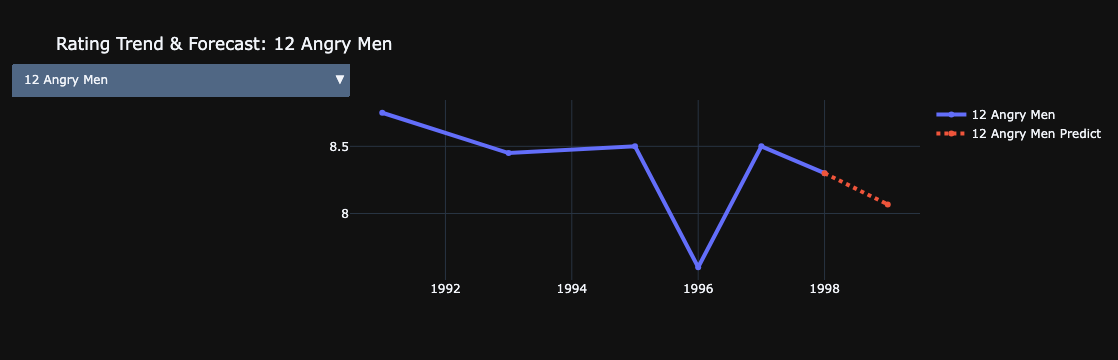

In [33]:
# ── INTERACTIVE FORECASTER ──
import plotly.graph_objects as go
df_v = pd.read_csv('movie_data_professional.csv')
agg = df_v.groupby(['Movie Title', 'Review_Year']).agg(
    P=('BERT_Sentiment', lambda x: (x == 'Positive').mean()),
    R=('Review_Rating', 'mean')
).reset_index()
movies = sorted(agg['Movie Title'].unique())
fig = go.Figure()

for m in movies:
    d = agg[agg['Movie Title'] == m].sort_values('Review_Year')
    X_f = d['Review_Year'].values.reshape(-1, 1); y_f = d['R'].values
    mod = LinearRegression().fit(X_f, y_f)
    ny = int(d['Review_Year'].max() + 1); pred = np.clip(mod.predict([[ny]])[0], 1, 10)
    
    # History
    fig.add_trace(go.Scatter(x=d['Review_Year'], y=d['R'], name=m, mode='lines+markers', line=dict(width=4), visible=(m==movies[0])))
    # Forecast
    fig.add_trace(go.Scatter(x=[d['Review_Year'].max(), ny], y=[d['R'].iloc[-1], pred], name=f"{m} Predict", mode='lines+markers', line=dict(width=4, dash='dot'), visible=(m==movies[0])))

buttons = []
for i, m in enumerate(movies):
    vis = [False] * (len(movies)*2); vis[i*2] = vis[i*2+1] = True
    buttons.append(dict(label=m, method="update", args=[{"visible": vis}, {"title": f"Historical Trend & {ny} Forecast: {m}"}]))

fig.update_layout(updatemenus=[dict(active=0, buttons=buttons, y=1.2, x=0)], template='plotly_dark', title=f"Rating Trend & Forecast: {movies[0]}").show()